In [136]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [137]:
df = pd.read_csv('House Price.csv')
df.shape

(29451, 12)

In [138]:
df.head()

,POSTED_BY,UNDER_CONSTRUCTION,RERA,BHK_NO.,BHK_OR_RK,SQUARE_FT,READY_TO_MOVE,RESALE,ADDRESS,LONGITUDE,LATITUDE,TARGET(PRICE_IN_LACS)
0,Owner,0,0,2,BHK,1300.236407,1,1,"Ksfc Layout,Bangalore",12.969910,77.597960,55.0
1,Dealer,0,0,2,BHK,1275.000000,1,1,"Vishweshwara Nagar,Mysore",12.274538,76.644605,51.0
2,Owner,0,0,2,BHK,933.159722,1,1,"Jigani,Bangalore",12.778033,77.632191,43.0
3,Owner,0,1,2,BHK,929.921143,1,1,"Sector-1 Vaishali,Ghaziabad",28.642300,77.344500,62.5
4,Dealer,1,0,2,BHK,999.009247,0,1,"New Town,Kolkata",22.592200,88.484911,60.5


# Exploratory Data Analysis (EDA)

In [139]:
# Dataset Information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 29451 entries, 0 to 29450
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   POSTED_BY              29451 non-null  str    
 1   UNDER_CONSTRUCTION     29451 non-null  int64  
 2   RERA                   29451 non-null  int64  
 3   BHK_NO.                29451 non-null  int64  
 4   BHK_OR_RK              29451 non-null  str    
 5   SQUARE_FT              29451 non-null  float64
 6   READY_TO_MOVE          29451 non-null  int64  
 7   RESALE                 29451 non-null  int64  
 8   ADDRESS                29451 non-null  str    
 9   LONGITUDE              29451 non-null  float64
 10  LATITUDE               29451 non-null  float64
 11  TARGET(PRICE_IN_LACS)  29451 non-null  float64
dtypes: float64(4), int64(5), str(3)
memory usage: 3.5 MB


In [140]:
#Statistical Summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
UNDER_CONSTRUCTION,29451.0,0.179756,3.839908e-01,0.000000,0.000000,0.000000,0.000000,1.000000e+00
RERA,29451.0,0.317918,4.656753e-01,0.000000,0.000000,0.000000,1.000000,1.000000e+00
BHK_NO.,29451.0,2.392279,8.790913e-01,1.000000,2.000000,2.000000,3.000000,2.000000e+01
SQUARE_FT,29451.0,19802.170190,1.901335e+06,3.000000,900.021130,1175.056750,1550.688124,2.545455e+08
READY_TO_MOVE,29451.0,0.820244,3.839908e-01,0.000000,1.000000,1.000000,1.000000,1.000000e+00
RESALE,29451.0,0.929578,2.558613e-01,0.000000,1.000000,1.000000,1.000000,1.000000e+00
LONGITUDE,29451.0,21.300255,6.205306e+00,-37.713008,18.452663,20.750000,26.900926,5.991288e+01
LATITUDE,29451.0,76.837695,1.055775e+01,-121.761248,73.798100,77.324137,77.828740,1.529627e+02
TARGET(PRICE_IN_LACS),29451.0,142.898746,6.568807e+02,0.250000,38.000000,62.000000,100.000000,3.000000e+04


In [141]:
#Include Categorical Columns
df.describe(include='object')

,POSTED_BY,BHK_OR_RK,ADDRESS
count,29451,29451,29451
unique,3,2,6899
top,Dealer,BHK,"Zirakpur,Chandigarh"
freq,18291,29427,509


In [142]:
#Check Data Types
df.dtypes

POSTED_BY                    str
UNDER_CONSTRUCTION         int64
RERA                       int64
BHK_NO.                    int64
BHK_OR_RK                    str
SQUARE_FT                float64
READY_TO_MOVE              int64
RESALE                     int64
ADDRESS                      str
LONGITUDE                float64
LATITUDE                 float64
TARGET(PRICE_IN_LACS)    float64
dtype: object

In [143]:
#Column Names
df.columns

Index(['POSTED_BY', 'UNDER_CONSTRUCTION', 'RERA', 'BHK_NO.', 'BHK_OR_RK',
       'SQUARE_FT', 'READY_TO_MOVE', 'RESALE', 'ADDRESS', 'LONGITUDE',
       'LATITUDE', 'TARGET(PRICE_IN_LACS)'],
      dtype='str')

In [144]:
#Shape Again
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 29451
Columns : 12


In [145]:
#Sample Records
df.sample(5)

,POSTED_BY,UNDER_CONSTRUCTION,RERA,BHK_NO.,BHK_OR_RK,SQUARE_FT,READY_TO_MOVE,RESALE,ADDRESS,LONGITUDE,LATITUDE,TARGET(PRICE_IN_LACS)
7981,Dealer,0,1,2,BHK,1297.149684,1,1,"Wakad,Pune",18.59930,73.762500,76.0
11869,Dealer,0,1,3,BHK,1418.115279,1,1,"Kasavanhalli,Bangalore",12.90770,77.675500,93.0
8270,Dealer,0,0,3,BHK,1600.000000,1,1,"Chandivali,Maharashtra",18.58584,73.471734,250.0
18704,Dealer,0,1,3,BHK,1769.911504,1,1,"Manapakkam,Chennai",13.01330,80.172860,100.0
15415,Owner,0,0,2,BHK,1000.000000,1,1,"Sector II - Salt Lake,Kolkata",22.54111,88.337780,46.0


In [146]:
#missing Values
df.isnull().sum()

POSTED_BY                0
UNDER_CONSTRUCTION       0
RERA                     0
BHK_NO.                  0
BHK_OR_RK                0
SQUARE_FT                0
READY_TO_MOVE            0
RESALE                   0
ADDRESS                  0
LONGITUDE                0
LATITUDE                 0
TARGET(PRICE_IN_LACS)    0
dtype: int64

In [147]:
#duplicate Records
df.duplicated().sum()

np.int64(401)

In [148]:
#Unique Values
df.nunique().sort_values()

UNDER_CONSTRUCTION           2
RERA                         2
READY_TO_MOVE                2
BHK_OR_RK                    2
RESALE                       2
POSTED_BY                    3
BHK_NO.                     16
TARGET(PRICE_IN_LACS)     1172
LATITUDE                  4078
LONGITUDE                 4087
ADDRESS                   6899
SQUARE_FT                19561
dtype: int64

In [149]:
#Value Counts
df['POSTED_BY'].value_counts()

POSTED_BY
Dealer     18291
Owner      10538
Builder      622
Name: count, dtype: int64

In [150]:
df['UNDER_CONSTRUCTION'].value_counts()

UNDER_CONSTRUCTION
0    24157
1     5294
Name: count, dtype: int64

In [151]:
df['RERA'].value_counts()

RERA
0    20088
1     9363
Name: count, dtype: int64

In [152]:
df['BHK_OR_RK'].value_counts()

BHK_OR_RK
BHK    29427
RK        24
Name: count, dtype: int64

In [153]:
df['READY_TO_MOVE'].value_counts()

READY_TO_MOVE
1    24157
0     5294
Name: count, dtype: int64

In [154]:
df['RESALE'].value_counts()

RESALE
1    27377
0     2074
Name: count, dtype: int64

In [155]:
df['TARGET(PRICE_IN_LACS)'].describe()

count    29451.000000
mean       142.898746
std        656.880713
min          0.250000
25%         38.000000
50%         62.000000
75%        100.000000
max      30000.000000
Name: TARGET(PRICE_IN_LACS), dtype: float64

In [156]:
df['TARGET(PRICE_IN_LACS)'].skew()

np.float64(17.583332275535085)

In [157]:
#Check Numeric Columns
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

numeric_columns

Index(['UNDER_CONSTRUCTION', 'RERA', 'BHK_NO.', 'SQUARE_FT', 'READY_TO_MOVE',
       'RESALE', 'LONGITUDE', 'LATITUDE', 'TARGET(PRICE_IN_LACS)'],
      dtype='str')

In [158]:
df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
UNDER_CONSTRUCTION,29451.0,0.179756,3.839908e-01,0.000000,0.000000,0.000000,0.000000,1.000000e+00
RERA,29451.0,0.317918,4.656753e-01,0.000000,0.000000,0.000000,1.000000,1.000000e+00
BHK_NO.,29451.0,2.392279,8.790913e-01,1.000000,2.000000,2.000000,3.000000,2.000000e+01
SQUARE_FT,29451.0,19802.170190,1.901335e+06,3.000000,900.021130,1175.056750,1550.688124,2.545455e+08
READY_TO_MOVE,29451.0,0.820244,3.839908e-01,0.000000,1.000000,1.000000,1.000000,1.000000e+00
RESALE,29451.0,0.929578,2.558613e-01,0.000000,1.000000,1.000000,1.000000,1.000000e+00
LONGITUDE,29451.0,21.300255,6.205306e+00,-37.713008,18.452663,20.750000,26.900926,5.991288e+01
LATITUDE,29451.0,76.837695,1.055775e+01,-121.761248,73.798100,77.324137,77.828740,1.529627e+02
TARGET(PRICE_IN_LACS),29451.0,142.898746,6.568807e+02,0.250000,38.000000,62.000000,100.000000,3.000000e+04


In [159]:
#Check Categorical Columns
categorical_columns = df.select_dtypes(include='object').columns

categorical_columns

Index(['POSTED_BY', 'BHK_OR_RK', 'ADDRESS'], dtype='str')

In [160]:
for col in categorical_columns:
    print("="*50)
    print(col)
    print(df[col].value_counts().head(10))

POSTED_BY
POSTED_BY
Dealer     18291
Owner      10538
Builder      622
Name: count, dtype: int64
BHK_OR_RK
BHK_OR_RK
BHK    29427
RK        24
Name: count, dtype: int64
ADDRESS
ADDRESS
Zirakpur,Chandigarh              509
Whitefield,Bangalore             230
Raj Nagar Extension,Ghaziabad    215
Sector-137 Noida,Noida           139
New Town,Kolkata                 131
Jagatpura,Jaipur                 120
Rajarhat,Kolkata                 113
Thanisandra,Bangalore            110
Noida Extension,Noida            107
Baner,Pune                       101
Name: count, dtype: int64


In [161]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

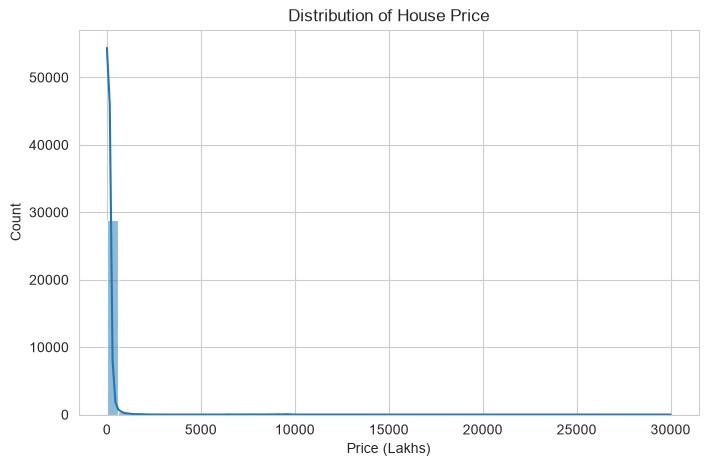

In [162]:
#Visualize the Target Variable
plt.figure(figsize=(8,5))
sns.histplot(df["TARGET(PRICE_IN_LACS)"], bins=50, kde=True)

plt.title("Distribution of House Price")
plt.xlabel("Price (Lakhs)")
plt.ylabel("Count")

plt.show()

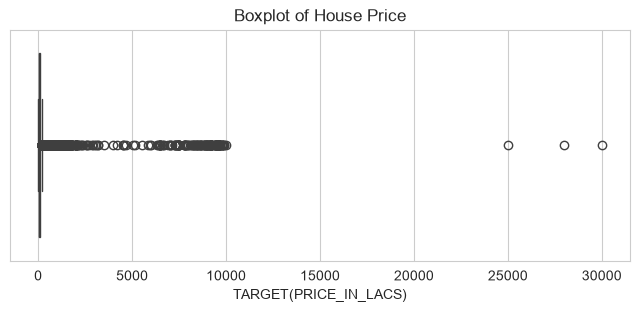

In [163]:
#Boxplot of the Target Variable
plt.figure(figsize=(8,3))

sns.boxplot(x=df["TARGET(PRICE_IN_LACS)"])

plt.title("Boxplot of House Price")

plt.show()

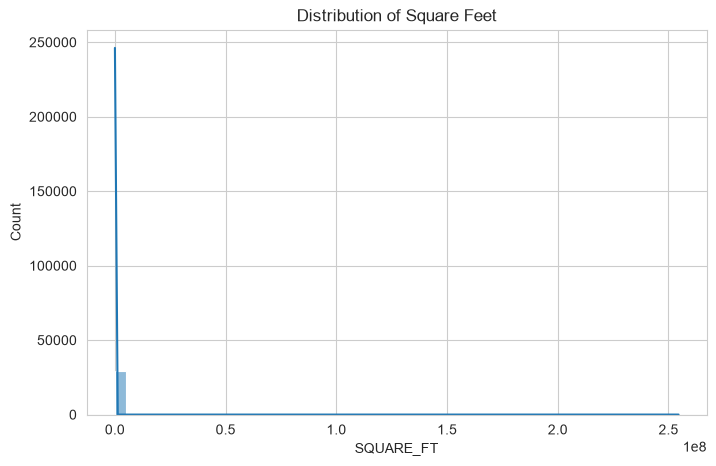

In [164]:
#Distribution of Square Feet
plt.figure(figsize=(8,5))

sns.histplot(df["SQUARE_FT"], bins=50, kde=True)

plt.title("Distribution of Square Feet")

plt.show()

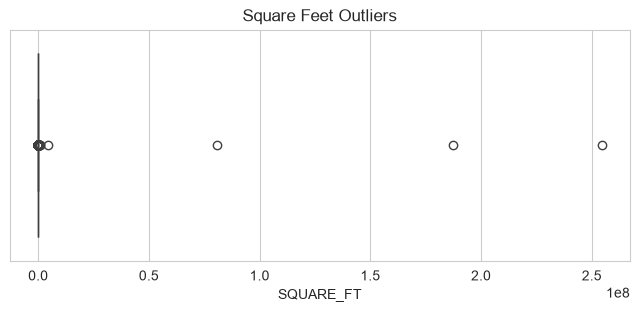

In [165]:
#Boxplot of Square Feet
plt.figure(figsize=(8,3))

sns.boxplot(x=df["SQUARE_FT"])

plt.title("Square Feet Outliers")

plt.show()

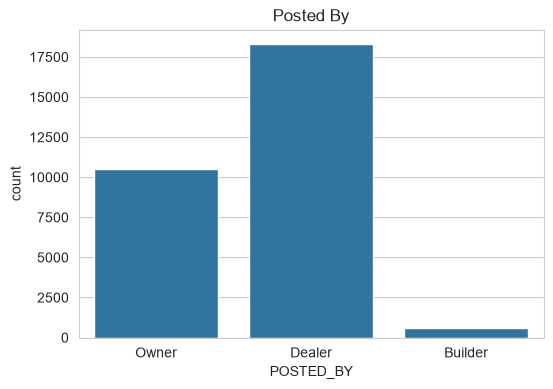

In [166]:
#Count Plot of POSTED_BY
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="POSTED_BY")

plt.title("Posted By")

plt.show()

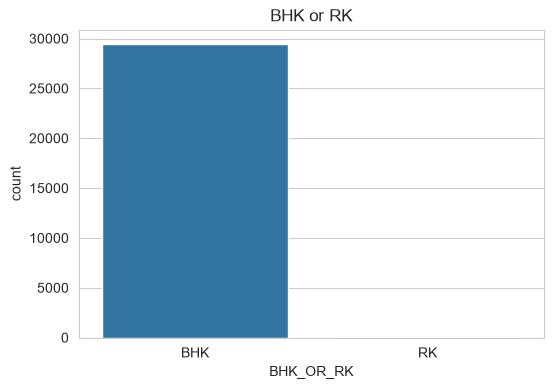

In [167]:
#Count Plot of BHK_OR_RK
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="BHK_OR_RK")

plt.title("BHK or RK")

plt.show()

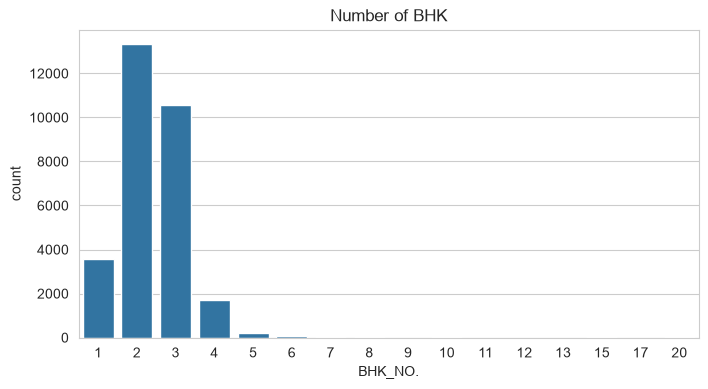

In [168]:
#Distribution of BHK_NO.
plt.figure(figsize=(8,4))

sns.countplot(data=df, x="BHK_NO.")

plt.title("Number of BHK")

plt.show()

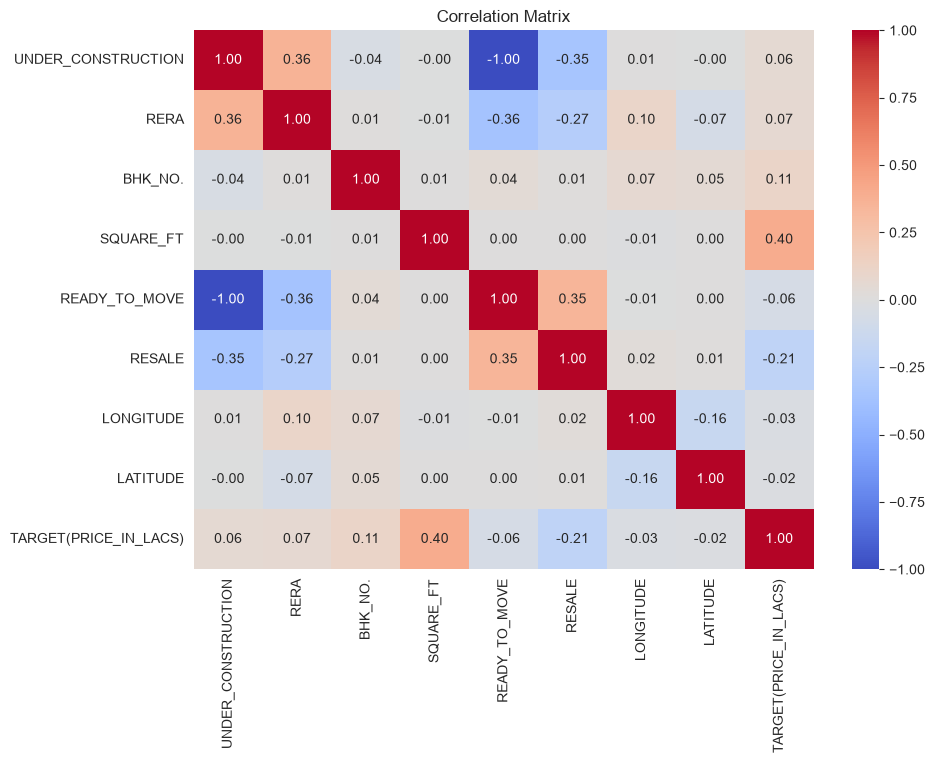

In [169]:
#Correlation Matrix (Numeric Columns)
plt.figure(figsize=(10,7))

sns.heatmap(
    df.select_dtypes(include=["int64", "float64"]).corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()



# Exploratory Data Analysis (EDA)

### **Purpose**

Exploratory Data Analysis (EDA) is performed to understand the structure, distribution, and characteristics of the dataset before applying machine learning algorithms. It helps identify data patterns, detect anomalies, discover relationships among variables, and understand the target variable. The insights obtained from EDA guide decisions regarding data preprocessing, feature engineering, and model selection.

### **Objectives of EDA**

* Understand the distribution of numerical and categorical features.
* Analyze the distribution of the target variable (House Price).
* Detect the presence of outliers and extreme values.
* Study relationships between features and the target variable.
* Examine correlations among numerical variables.
* Identify potential issues that may affect model performance.

---

# Distribution of House Price

### **Explanation**

The histogram is used to visualize the distribution of the target variable **TARGET(PRICE_IN_LACS)**. This plot helps determine whether the house prices follow a normal distribution or are skewed. Understanding the target distribution is important because many regression algorithms perform better when the target variable has a relatively normal distribution.

---

# Boxplot of House Price

### **Explanation**

The boxplot is used to detect outliers in the target variable. It provides a visual representation of the median, quartiles, and extreme values. This analysis helps determine whether unusually expensive properties exist in the dataset and whether further investigation or transformation is required before model training.

---

# Distribution of Square Feet

### **Explanation**

The histogram of **SQUARE_FT** is used to understand the distribution of property sizes. It helps identify whether the feature is normally distributed, positively skewed, or contains unusually large property sizes that may influence the prediction model.

---

# Boxplot of Square Feet

### **Explanation**

The boxplot is used to identify extreme property size values (outliers). Detecting these observations is important because unrealistic or erroneous values may negatively impact the performance of regression algorithms.

---

# Distribution of Property Posted By

### **Explanation**

The count plot displays the frequency of property listings posted by different categories such as **Owner**, **Dealer**, and **Builder**. This analysis helps understand the composition of the dataset and whether any category dominates the listings.

---

# Distribution of Property Type (BHK / RK)

### **Explanation**

The count plot illustrates the frequency of different property types available in the dataset. It helps understand whether the dataset is balanced across property types and whether certain categories have very limited observations.

---

# Distribution of Number of Bedrooms (BHK)

### **Explanation**

The count plot of **BHK_NO.** shows the number of properties belonging to each bedroom category. This analysis provides insight into the most common residential property configurations and helps understand customer demand patterns.

---

# Correlation Analysis

### **Explanation**

A correlation heatmap is generated to measure the strength and direction of linear relationships between numerical variables. Correlation values range from **-1 to +1**, where:

* **+1** indicates a perfect positive relationship.
* **-1** indicates a perfect negative relationship.
* **0** indicates no linear relationship.

Understanding feature correlations helps identify variables that are strongly associated with the target variable and detects highly correlated features that may introduce redundancy in the predictive model.

---

# Conclusion of EDA

### **Explanation**

The exploratory analysis provides valuable insights into the dataset by highlighting the distribution of features, identifying outliers, and understanding relationships among variables. These findings form the foundation for the next phase of the project, which includes detailed outlier analysis, data preprocessing, feature engineering, encoding categorical variables, and preparing the dataset for machine learning model development.



In [170]:
#Duplicate Treatment
# Total duplicate rows
duplicate_count = df.duplicated().sum()

print("Duplicate Rows:", duplicate_count)

Duplicate Rows: 401


In [171]:
# Display all duplicate rows
duplicates = df[df.duplicated(keep=False)]

duplicates.sort_values(by=list(df.columns))

,POSTED_BY,UNDER_CONSTRUCTION,RERA,BHK_NO.,BHK_OR_RK,SQUARE_FT,READY_TO_MOVE,RESALE,ADDRESS,LONGITUDE,LATITUDE,TARGET(PRICE_IN_LACS)
7020,Builder,0,0,1,BHK,422.153369,1,0,"Hoshangabad Road,Bhopal",22.750000,77.720000,10.9
26748,Builder,0,0,1,BHK,422.153369,1,0,"Hoshangabad Road,Bhopal",22.750000,77.720000,10.9
18061,Builder,1,0,3,BHK,979.290979,0,0,"Barasat,Kolkata",22.747639,88.600902,27.9
29389,Builder,1,0,3,BHK,979.290979,0,0,"Barasat,Kolkata",22.747639,88.600902,27.9
17114,Builder,1,1,3,BHK,1500.000000,0,0,"ECR,Chennai",12.931889,80.252422,69.0
...,...,...,...,...,...,...,...,...,...,...,...,...
15338,Owner,1,1,2,BHK,558.121632,0,1,"Jhalamand,Jodhpur",26.207200,73.066000,14.5
3816,Owner,1,1,2,BHK,759.436107,0,1,"Gotal Pajri,Nagpur",21.000000,79.000000,16.7
10569,Owner,1,1,2,BHK,759.436107,0,1,"Gotal Pajri,Nagpur",21.000000,79.000000,16.7
19332,Owner,1,1,2,BHK,1190.168176,0,1,"Somalwada,Nagpur",21.096220,79.065033,46.0


In [172]:
# Remove duplicate rows

df = df.drop_duplicates()

# Verify removal

print("Dataset Shape:", df.shape)
print("Duplicate Rows:", df.duplicated().sum())

Dataset Shape: (29050, 12)
Duplicate Rows: 0


# Duplicate Records

- The dataset contained 401 duplicate rows. Since these records were exact duplicates across all features and the target variable, they did not contribute additional information to the analysis. Therefore, duplicate rows were removed to improve data quality and avoid potential bias during model training.

# OUTLIER ANALYSIS

In [173]:
# Quantiles of Target Variable

price_quantiles = df["TARGET(PRICE_IN_LACS)"].quantile(
    [0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 0.995, 0.999, 1.00]
)

price_quantiles

0.250       38.00
0.500       61.75
0.750      100.00
0.900      200.00
0.950      300.00
0.990     1000.00
0.995     2887.75
0.999     9500.00
1.000    30000.00
Name: TARGET(PRICE_IN_LACS), dtype: float64

In [174]:
#Square Feet Quantiles
# Quantiles of Square Feet

sqft_quantiles = df["SQUARE_FT"].quantile(
    [0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 0.995, 0.999, 1.00]
)

sqft_quantiles

0.250    9.000000e+02
0.500    1.172742e+03
0.750    1.550169e+03
0.900    2.049713e+03
0.950    2.614671e+03
0.990    5.399797e+03
0.995    2.195604e+04
0.999    1.544202e+05
1.000    2.545455e+08
Name: SQUARE_FT, dtype: float64

In [175]:
#Houses Costing More Than ₹1000 Lakhs
# Properties with Price > 1000 Lakhs

expensive_houses = df[df["TARGET(PRICE_IN_LACS)"] > 1000]

print("Number of Houses:", expensive_houses.shape[0])

expensive_houses

Number of Houses: 289


,POSTED_BY,UNDER_CONSTRUCTION,RERA,BHK_NO.,BHK_OR_RK,SQUARE_FT,READY_TO_MOVE,RESALE,ADDRESS,LONGITUDE,LATITUDE,TARGET(PRICE_IN_LACS)
40,Dealer,1,1,1,BHK,40606.195680,0,0,"Kanjur Marg (East),Lalitpur",24.690280,78.418890,9110.0
160,Dealer,0,0,4,BHK,6974.645114,1,1,"New Alipore,Kolkata",22.530280,88.334170,1700.0
294,Builder,1,1,3,BHK,106469.002700,0,0,"Vishrantwadi,Lalitpur",24.690280,78.418890,9480.0
347,Dealer,0,0,4,BHK,4299.996417,1,1,"Andheri (West),Mumbai",19.139348,72.820458,1200.0
361,Dealer,1,1,6,BHK,10050.251260,0,1,"Sector-124 Noida,Noida",28.548382,77.327819,1200.0
...,...,...,...,...,...,...,...,...,...,...,...,...
28925,Dealer,0,1,2,BHK,63986.013990,1,0,"Kolshet Road,Lalitpur",24.690280,78.418890,9150.0
28994,Dealer,0,0,4,BHK,3204.952611,1,1,"Hiranandani Gardens - Powai,Lalitpur",19.124896,72.893503,1170.0
29002,Builder,1,1,3,BHK,157454.545500,0,0,"8th Phase JP Nagar,Bangalore",12.905368,77.580403,8660.0
29187,Owner,0,0,20,BHK,16860.563140,1,1,"Seethammadhara,Visakhapatnam",17.741878,83.308875,2000.0


In [176]:
#Houses Larger Than 10,000 Sq Ft
# Properties with Square Feet > 10000

large_houses = df[df["SQUARE_FT"] > 10000]

print("Number of Houses:", large_houses.shape[0])

large_houses

Number of Houses: 182


,POSTED_BY,UNDER_CONSTRUCTION,RERA,BHK_NO.,BHK_OR_RK,SQUARE_FT,READY_TO_MOVE,RESALE,ADDRESS,LONGITUDE,LATITUDE,TARGET(PRICE_IN_LACS)
40,Dealer,1,1,1,BHK,40606.19568,0,0,"Kanjur Marg (East),Lalitpur",24.690280,78.418890,9110.0
294,Builder,1,1,3,BHK,106469.00270,0,0,"Vishrantwadi,Lalitpur",24.690280,78.418890,9480.0
361,Dealer,1,1,6,BHK,10050.25126,0,1,"Sector-124 Noida,Noida",28.548382,77.327819,1200.0
373,Owner,0,0,4,BHK,433333.33330,1,1,"Mulanthuruthy,Kochi",9.893479,76.408774,65.0
554,Dealer,1,1,3,BHK,113785.55800,0,0,"Dabolim,Goa",15.384909,73.850001,7280.0
...,...,...,...,...,...,...,...,...,...,...,...,...
28925,Dealer,0,1,2,BHK,63986.01399,1,0,"Kolshet Road,Lalitpur",24.690280,78.418890,9150.0
29002,Builder,1,1,3,BHK,157454.54550,0,0,"8th Phase JP Nagar,Bangalore",12.905368,77.580403,8660.0
29187,Owner,0,0,20,BHK,16860.56314,1,1,"Seethammadhara,Visakhapatnam",17.741878,83.308875,2000.0
29293,Dealer,0,0,1,BHK,21739.13043,1,1,"Kolad,Lalitpur",24.690280,78.418890,35.0


In [177]:
#Top 20 Most Expensive Houses
top_price = df.nlargest(20, "TARGET(PRICE_IN_LACS)")

top_price

,POSTED_BY,UNDER_CONSTRUCTION,RERA,BHK_NO.,BHK_OR_RK,SQUARE_FT,READY_TO_MOVE,RESALE,ADDRESS,LONGITUDE,LATITUDE,TARGET(PRICE_IN_LACS)
11238,Dealer,0,0,3,BHK,1.875000e+08,1,1,"R.T. Nagar,Bangalore",13.018900,77.596300,30000.0
10745,Owner,0,0,3,BHK,2.545455e+08,1,1,"Malur,Bangalore",13.021000,77.938000,28000.0
15724,Owner,0,0,2,BHK,8.064516e+07,1,1,"Lakkasandra,Bangalore",12.795926,77.331535,25000.0
5967,Dealer,1,1,2,BHK,5.422570e+04,0,0,"Thane West,Lalitpur",19.180000,72.963330,9990.0
10637,Dealer,1,1,3,BHK,8.322835e+04,0,0,"Chinchwad,Pune",18.627000,73.782900,9910.0
3754,Dealer,1,1,1,BHK,4.272398e+04,0,0,"Kanjur Marg (East),Maharashtra",18.960000,72.820000,9900.0
9799,Dealer,1,1,2,BHK,4.968975e+04,0,0,"Laxmi Nagar,Mumbai",22.281215,70.789479,9850.0
14519,Dealer,0,1,1,BHK,4.377345e+04,1,0,"Hiranandani Estate,Lalitpur",19.255098,72.981527,9800.0
15225,Dealer,0,0,3,BHK,1.652321e+05,1,0,"Sector-150 Noida,Noida",28.429614,77.481711,9790.0
4520,Dealer,1,1,3,BHK,1.394286e+05,0,0,"Sector-150 Noida,Noida",28.429614,77.481711,9760.0


In [178]:
#Top 20 Largest Houses
top_sqft = df.nlargest(20, "SQUARE_FT")

top_sqft

,POSTED_BY,UNDER_CONSTRUCTION,RERA,BHK_NO.,BHK_OR_RK,SQUARE_FT,READY_TO_MOVE,RESALE,ADDRESS,LONGITUDE,LATITUDE,TARGET(PRICE_IN_LACS)
10745,Owner,0,0,3,BHK,2.545455e+08,1,1,"Malur,Bangalore",13.021000,77.938000,28000.0
11238,Dealer,0,0,3,BHK,1.875000e+08,1,1,"R.T. Nagar,Bangalore",13.018900,77.596300,30000.0
15724,Owner,0,0,2,BHK,8.064516e+07,1,1,"Lakkasandra,Bangalore",12.795926,77.331535,25000.0
25241,Owner,0,0,3,BHK,4.300000e+06,1,1,"New Kumaran Nagar,Chennai",10.810426,78.668914,43.0
28591,Owner,0,0,2,BHK,8.750000e+05,1,1,"Ajit Singh Nagar,Vijayawada",30.466084,74.501902,35.0
15598,Owner,0,0,3,BHK,7.928571e+05,1,1,"Sainik Colony,Jammu",32.674044,74.907348,55.5
373,Owner,0,0,4,BHK,4.333333e+05,1,1,"Mulanthuruthy,Kochi",9.893479,76.408774,65.0
22155,Owner,0,0,1,BHK,3.400000e+05,1,1,"Sayajipura,Vadodara",22.323406,73.240395,17.0
19047,Dealer,1,1,4,BHK,2.460088e+05,0,0,"Gomti Nagar Extension,Lucknow",21.000000,77.000000,9523.0
13035,Builder,0,0,4,BHK,2.425000e+05,1,0,"Bariatu,Ranchi",23.399528,85.357421,9700.0


In [179]:
#Check Outliers Using IQR (Price)
Q1 = df["TARGET(PRICE_IN_LACS)"].quantile(0.25)
Q3 = df["TARGET(PRICE_IN_LACS)"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower Bound :", lower)
print("Upper Bound :", upper)

Lower Bound : -55.0
Upper Bound : 193.0


In [180]:
#Number of Price Outliers
price_outliers = df[
    (df["TARGET(PRICE_IN_LACS)"] < lower) |
    (df["TARGET(PRICE_IN_LACS)"] > upper)
]

print("Number of Price Outliers :", price_outliers.shape[0])

price_outliers.head()

Number of Price Outliers : 3045


,POSTED_BY,UNDER_CONSTRUCTION,RERA,BHK_NO.,BHK_OR_RK,SQUARE_FT,READY_TO_MOVE,RESALE,ADDRESS,LONGITUDE,LATITUDE,TARGET(PRICE_IN_LACS)
23,Dealer,0,0,1,BHK,630.000630,1,1,"Bandra (West),Mumbai",19.054440,72.840560,300.0
34,Dealer,0,1,2,BHK,857.786197,1,0,"Mulund (West),Maharashtra",19.175900,72.952200,240.0
40,Dealer,1,1,1,BHK,40606.195680,0,0,"Kanjur Marg (East),Lalitpur",24.690280,78.418890,9110.0
43,Dealer,0,1,3,BHK,1274.924779,1,1,"Marol,Mumbai",22.803593,83.755013,250.0
44,Dealer,0,0,2,BHK,1026.694045,1,1,"Wadala East,Lalitpur",19.014858,72.866200,220.0


In [181]:
#Check Outliers Using IQR (Square Feet)
Q1 = df["SQUARE_FT"].quantile(0.25)
Q3 = df["SQUARE_FT"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower Bound :", lower)
print("Upper Bound :", upper)

Lower Bound : -75.2536634999999
Upper Bound : 2525.4227725


In [182]:
#Number of Square Feet Outliers
sqft_outliers = df[
    (df["SQUARE_FT"] < lower) |
    (df["SQUARE_FT"] > upper)
]

print("Number of Square Feet Outliers :", sqft_outliers.shape[0])

sqft_outliers.head()

Number of Square Feet Outliers : 1612


,POSTED_BY,UNDER_CONSTRUCTION,RERA,BHK_NO.,BHK_OR_RK,SQUARE_FT,READY_TO_MOVE,RESALE,ADDRESS,LONGITUDE,LATITUDE,TARGET(PRICE_IN_LACS)
40,Dealer,1,1,1,BHK,40606.195680,0,0,"Kanjur Marg (East),Lalitpur",24.690280,78.418890,9110.0
57,Owner,0,1,4,BHK,5200.945626,1,1,"Sector-76 Noida,Noida",28.567633,77.383124,110.0
68,Owner,0,0,2,BHK,5000.000000,1,1,"Malviya Nagar,Jaipur",26.850391,75.814198,85.0
92,Owner,0,0,3,BHK,2738.225630,1,1,"Basapura,Bangalore",12.863421,77.652405,150.0
117,Dealer,0,0,4,BHK,2750.929368,1,1,"Sikandra,Agra",27.216013,77.950834,74.0


# Transform the target

In [183]:
import numpy as np

df["TARGET_LOG"] = np.log1p(df["TARGET(PRICE_IN_LACS)"])

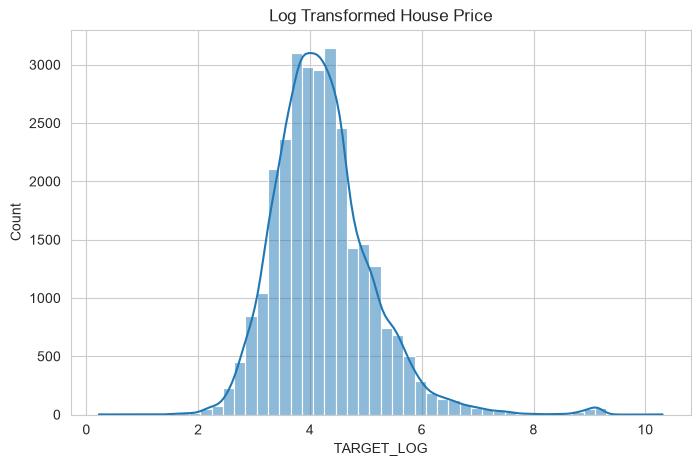

In [184]:
plt.figure(figsize=(8,5))

sns.histplot(df["TARGET_LOG"], bins=50, kde=True)

plt.title("Log Transformed House Price")

plt.show()

In [185]:
df["TARGET_LOG"].skew()

np.float64(1.202083047800571)

In [186]:
df[numeric_columns].skew()

UNDER_CONSTRUCTION         1.675076
RERA                       0.792238
BHK_NO.                    2.411951
SQUARE_FT                115.812901
READY_TO_MOVE             -1.675076
RESALE                    -3.381700
LONGITUDE                  0.185040
LATITUDE                 -10.322082
TARGET(PRICE_IN_LACS)     17.971976
dtype: float64

In [187]:
# inspect the largest values:

df.nlargest(20, "SQUARE_FT")[["SQUARE_FT", "ADDRESS", "TARGET(PRICE_IN_LACS)"]]

,SQUARE_FT,ADDRESS,TARGET(PRICE_IN_LACS)
10745,2.545455e+08,"Malur,Bangalore",28000.0
11238,1.875000e+08,"R.T. Nagar,Bangalore",30000.0
15724,8.064516e+07,"Lakkasandra,Bangalore",25000.0
25241,4.300000e+06,"New Kumaran Nagar,Chennai",43.0
28591,8.750000e+05,"Ajit Singh Nagar,Vijayawada",35.0
15598,7.928571e+05,"Sainik Colony,Jammu",55.5
373,4.333333e+05,"Mulanthuruthy,Kochi",65.0
22155,3.400000e+05,"Sayajipura,Vadodara",17.0
19047,2.460088e+05,"Gomti Nagar Extension,Lucknow",9523.0
13035,2.425000e+05,"Bariatu,Ranchi",9700.0


In [188]:
#Create a copy for preprocessing
df_model = df.copy()

In [189]:
#Remove the original target
df_model = df_model.drop(columns=["TARGET(PRICE_IN_LACS)"])

In [190]:
#Feature Engineering on ADDRESS
df_model["CITY"] = (
    df_model["ADDRESS"]
    .str.split(",")
    .str[-1]
    .str.strip()
)

In [191]:
#inspection
print(df_model["CITY"].nunique())
df_model["CITY"].value_counts().head(20)

256


CITY
Bangalore      4272
Lalitpur       2963
Mumbai         2006
Pune           1980
Noida          1718
Kolkata        1686
Maharashtra    1571
Chennai        1245
Ghaziabad      1070
Jaipur          950
Chandigarh      660
Faridabad       625
Mohali          533
Vadodara        509
Gurgaon         419
Surat           419
Nagpur          331
Lucknow         321
Indore          301
Bhubaneswar     231
Name: count, dtype: int64

In [192]:
df_model.head()

,POSTED_BY,UNDER_CONSTRUCTION,RERA,BHK_NO.,BHK_OR_RK,SQUARE_FT,READY_TO_MOVE,RESALE,ADDRESS,LONGITUDE,LATITUDE,TARGET_LOG,CITY
0,Owner,0,0,2,BHK,1300.236407,1,1,"Ksfc Layout,Bangalore",12.969910,77.597960,4.025352,Bangalore
1,Dealer,0,0,2,BHK,1275.000000,1,1,"Vishweshwara Nagar,Mysore",12.274538,76.644605,3.951244,Mysore
2,Owner,0,0,2,BHK,933.159722,1,1,"Jigani,Bangalore",12.778033,77.632191,3.784190,Bangalore
3,Owner,0,1,2,BHK,929.921143,1,1,"Sector-1 Vaishali,Ghaziabad",28.642300,77.344500,4.151040,Ghaziabad
4,Dealer,1,0,2,BHK,999.009247,0,1,"New Town,Kolkata",22.592200,88.484911,4.119037,Kolkata


In [193]:
#Train/Test Split
X = df_model.drop(columns=["TARGET_LOG"])
y = df_model["TARGET_LOG"]

# Feature Engineering & Data Transformation

In [194]:
#Check Remaining Unique Values
print("POSTED_BY :", df_model["POSTED_BY"].nunique())
print("BHK_OR_RK :", df_model["BHK_OR_RK"].nunique())
print("CITY :", df_model["CITY"].nunique())
print("ADDRESS :", df_model["ADDRESS"].nunique())

POSTED_BY : 3
BHK_OR_RK : 2
CITY : 256
ADDRESS : 6899


In [195]:
# Check Frequency of Cities
city_freq = df_model["CITY"].value_counts()

city_freq.head(20)

CITY
Bangalore      4272
Lalitpur       2963
Mumbai         2006
Pune           1980
Noida          1718
Kolkata        1686
Maharashtra    1571
Chennai        1245
Ghaziabad      1070
Jaipur          950
Chandigarh      660
Faridabad       625
Mohali          533
Vadodara        509
Gurgaon         419
Surat           419
Nagpur          331
Lucknow         321
Indore          301
Bhubaneswar     231
Name: count, dtype: int64

In [196]:
#Group Rare Cities
# Find frequency of each city
city_freq = df_model["CITY"].value_counts()

# Cities having fewer than 20 records
rare_cities = city_freq[city_freq < 20].index

print("Number of Rare Cities:", len(rare_cities))

Number of Rare Cities: 165


In [197]:
df_model['CITY'].unique()

array(['Bangalore', 'Mysore', 'Ghaziabad', 'Kolkata', 'Kochi', 'Jaipur',
       'Mohali', 'Chennai', 'Siliguri', 'Noida', 'Raigad', 'Bhubaneswar',
       'Wardha', 'Pune', 'Mumbai', 'Nagpur', 'Deoghar', 'Bhiwadi',
       'Faridabad', 'Lalitpur', 'Maharashtra', 'Vadodara',
       'Visakhapatnam', 'Vapi', 'Mangalore', 'Aurangabad', 'Ottapalam',
       'Vijayawada', 'Belgaum', 'Bhopal', 'Lucknow', 'Kanpur',
       'Gandhinagar', 'Pondicherry', 'Agra', 'Ranchi', 'Gurgaon', 'Udupi',
       'Indore', 'Jodhpur', 'Coimbatore', 'Valsad', 'Palghar', 'Surat',
       'Varanasi', 'Guwahati', 'Amravati', 'Anand', 'Tirupati',
       'Secunderabad', 'Raipur', 'Vizianagaram', 'Thrissur', 'Satna',
       'Madurai', 'Chandigarh', 'Shimla', 'Gwalior', 'Rajkot', 'Sonipat',
       'Allahabad', 'Berhampur', 'Roorkee', 'Dharuhera', 'Latur',
       'Durgapur', 'Panchkula', 'Solapur', 'Durg', 'Goa', 'Jamshedpur',
       'Hazaribagh', 'Jabalpur', 'Hosur', 'Morbi', 'Hubli', 'Karnal',
       'Patna', 'Bilaspur', '

- City Feature Engineering

- The CITY feature was extracted from the ADDRESS column to reduce the high cardinality of location information. This reduced the number of unique categories from 6,899 addresses to 256 cities, making the location feature more meaningful and easier to encode. Since city is an important factor influencing house prices, all city categories were retained for further analysis instead of grouping them into an "Other" category

In [198]:
# Find city frequencies
city_freq = df_model["CITY"].value_counts()

# Cities with fewer than 5 records
rare_cities = city_freq[city_freq < 5].index

# Replace rare cities with 'Other'
df_model["CITY"] = df_model["CITY"].replace(rare_cities, "Other")

# Check result
print("Unique Cities:", df_model["CITY"].nunique())
print(df_model["CITY"].value_counts().head(20))

Unique Cities: 148
CITY
Bangalore      4272
Lalitpur       2963
Mumbai         2006
Pune           1980
Noida          1718
Kolkata        1686
Maharashtra    1571
Chennai        1245
Ghaziabad      1070
Jaipur          950
Chandigarh      660
Faridabad       625
Mohali          533
Vadodara        509
Gurgaon         419
Surat           419
Nagpur          331
Lucknow         321
Indore          301
Bhubaneswar     231
Name: count, dtype: int64


- Handling Rare City Categories:
The CITY feature contained several categories with very few observations. Categories having fewer than 5 records were grouped into a new category named "Other". This reduces feature sparsity, minimizes overfitting, and improves the model's ability to generalize to unseen data while preserving information from the major cities.

In [199]:
city_freq = df_model["CITY"].value_counts()

print(city_freq.describe())
print(city_freq.tail(20))

count     148.000000
mean      196.283784
std       545.129580
min         5.000000
25%        10.750000
50%        32.000000
75%        85.750000
max      4272.000000
Name: count, dtype: float64
CITY
Eluru          7
Ongole         7
Rewari         7
Morbi          6
Muzaffarpur    6
Kollam         6
Palwal         6
Haldwani       6
Ujjain         6
Hosur          5
Anantapur      5
Gaya           5
Dharwad        5
Bokaro         5
Bhimavaram     5
Shirdi         5
Nadiad         5
Gulbarga       5
Jammu          5
Raigarh        5
Name: count, dtype: int64


# Feature Engineering

- The CITY feature was extracted from the ADDRESS column using the last element separated by a comma. Due to inconsistencies in the original dataset, some extracted values represent states or administrative regions instead of city names (e.g., "Maharashtra"). Since the correct city could not be determined without external data, these values were retained as separate categories to preserve the original information and avoid introducing incorrect assumptions.

In [200]:
df_model.columns

Index(['POSTED_BY', 'UNDER_CONSTRUCTION', 'RERA', 'BHK_NO.', 'BHK_OR_RK',
       'SQUARE_FT', 'READY_TO_MOVE', 'RESALE', 'ADDRESS', 'LONGITUDE',
       'LATITUDE', 'TARGET_LOG', 'CITY'],
      dtype='str')

In [201]:
# Remove trailing full stops and extra spaces from column names

df_model.columns = (
    df_model.columns
    .str.replace(".", "", regex=False)
    .str.strip()
)

df_model.columns

Index(['POSTED_BY', 'UNDER_CONSTRUCTION', 'RERA', 'BHK_NO', 'BHK_OR_RK',
       'SQUARE_FT', 'READY_TO_MOVE', 'RESALE', 'ADDRESS', 'LONGITUDE',
       'LATITUDE', 'TARGET_LOG', 'CITY'],
      dtype='str')

# Handle SQUARE_FT current skewness is

In [202]:
df_model['SQUARE_FT'].skew()

np.float64(115.81290137888708)

In [203]:
# Remove unrealistic property sizes

df_model = df_model[df_model["SQUARE_FT"] < 100000]

print("Dataset Shape:", df_model.shape)

Dataset Shape: (28982, 13)


In [204]:
#Check Skewness Again
print("Skewness :", df_model["SQUARE_FT"].skew())

Skewness : 19.4672737308339


In [205]:
# Log Transformation of Square Feet
df_model["SQUARE_FT_LOG"] = np.log1p(df_model["SQUARE_FT"])

In [206]:
print("Original Skewness :", df_model["SQUARE_FT"].skew())
print("Log Skewness      :", df_model["SQUARE_FT_LOG"].skew())

Original Skewness : 19.4672737308339
Log Skewness      : 1.0050610158413265


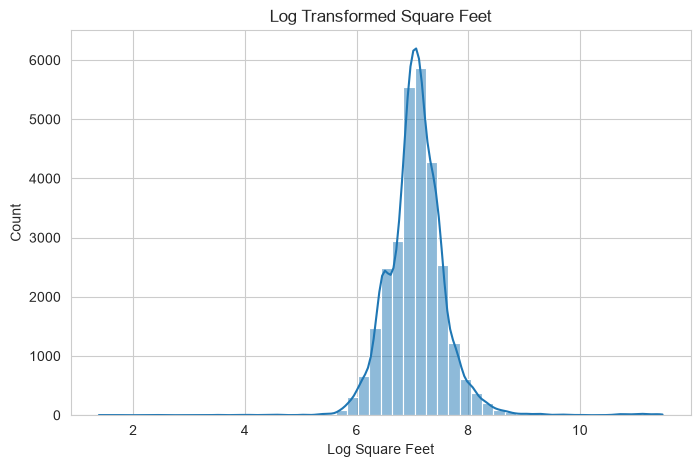

In [207]:
plt.figure(figsize=(8,5))

sns.histplot(df_model["SQUARE_FT_LOG"], bins=50, kde=True)

plt.title("Log Transformed Square Feet")
plt.xlabel("Log Square Feet")
plt.ylabel("Count")

plt.show()

In [208]:
# Drop original Square Feet column

df_model.drop(columns=["SQUARE_FT"], inplace=True)

# Verify columns
df_model.columns

Index(['POSTED_BY', 'UNDER_CONSTRUCTION', 'RERA', 'BHK_NO', 'BHK_OR_RK',
       'READY_TO_MOVE', 'RESALE', 'ADDRESS', 'LONGITUDE', 'LATITUDE',
       'TARGET_LOG', 'CITY', 'SQUARE_FT_LOG'],
      dtype='str')

### Log Transformation of Square Feet

- The SQUARE_FT feature exhibited a highly right-skewed distribution due to the presence of extremely large property sizes. After removing unrealistic values, a logarithmic transformation (log1p) was applied, reducing the skewness from 19.47 to 1.01. The transformed feature (SQUARE_FT_LOG) was retained for model development, while the original SQUARE_FT column was removed to avoid redundancy.

# Feature Encoding and Model Preparation

In [209]:
df_model.columns

Index(['POSTED_BY', 'UNDER_CONSTRUCTION', 'RERA', 'BHK_NO', 'BHK_OR_RK',
       'READY_TO_MOVE', 'RESALE', 'ADDRESS', 'LONGITUDE', 'LATITUDE',
       'TARGET_LOG', 'CITY', 'SQUARE_FT_LOG'],
      dtype='str')

In [210]:
df_model.info()

<class 'pandas.DataFrame'>
Index: 28982 entries, 0 to 29450
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   POSTED_BY           28982 non-null  str    
 1   UNDER_CONSTRUCTION  28982 non-null  int64  
 2   RERA                28982 non-null  int64  
 3   BHK_NO              28982 non-null  int64  
 4   BHK_OR_RK           28982 non-null  str    
 5   READY_TO_MOVE       28982 non-null  int64  
 6   RESALE              28982 non-null  int64  
 7   ADDRESS             28982 non-null  str    
 8   LONGITUDE           28982 non-null  float64
 9   LATITUDE            28982 non-null  float64
 10  TARGET_LOG          28982 non-null  float64
 11  CITY                28982 non-null  object 
 12  SQUARE_FT_LOG       28982 non-null  float64
dtypes: float64(4), int64(5), object(1), str(3)
memory usage: 3.9+ MB


In [211]:
#Drop ADDRESS

#Since you've already extracted CITY, the full ADDRESS has 6,899 unique values. 
# One-hot encoding it would create thousands of dummy variables and make the model unnecessarily complex.
df_model.drop(columns=["ADDRESS"], inplace=True)
df_model.columns

Index(['POSTED_BY', 'UNDER_CONSTRUCTION', 'RERA', 'BHK_NO', 'BHK_OR_RK',
       'READY_TO_MOVE', 'RESALE', 'LONGITUDE', 'LATITUDE', 'TARGET_LOG',
       'CITY', 'SQUARE_FT_LOG'],
      dtype='str')

- The original ADDRESS column contained a very high number of unique values (6,899), making it unsuitable for direct encoding. Since the CITY feature was extracted to represent location information in a simpler form, the ADDRESS column was removed to reduce dimensionality and improve model efficiency.

In [212]:
# Create Features and Target
# Features and Target

X = df_model.drop(columns=["TARGET_LOG"])
y = df_model["TARGET_LOG"]

print("Feature Shape :", X.shape)
print("Target Shape  :", y.shape)

Feature Shape : (28982, 11)
Target Shape  : (28982,)


In [213]:
# Identify Column Types
# Identify Numerical and Categorical Features

categorical_features = X.select_dtypes(include=["object", "string"]).columns.tolist()

numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)

Categorical Features:
['POSTED_BY', 'BHK_OR_RK', 'CITY']

Numerical Features:
['UNDER_CONSTRUCTION', 'RERA', 'BHK_NO', 'READY_TO_MOVE', 'RESALE', 'LONGITUDE', 'LATITUDE', 'SQUARE_FT_LOG']


In [214]:
#Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

Training Shape : (23185, 11)
Testing Shape  : (5797, 11)


### The dataset was divided into training and testing sets using an 80:20 ratio. The training set was used to build the machine learning models, while the testing set was reserved for evaluating model performance on unseen data.

# Machine Learning Phase

In [215]:
df_model

,POSTED_BY,UNDER_CONSTRUCTION,RERA,BHK_NO,BHK_OR_RK,READY_TO_MOVE,RESALE,LONGITUDE,LATITUDE,TARGET_LOG,CITY,SQUARE_FT_LOG
0,Owner,0,0,2,BHK,1,1,12.969910,77.597960,4.025352,Bangalore,7.171070
1,Dealer,0,0,2,BHK,1,1,12.274538,76.644605,3.951244,Mysore,7.151485
2,Owner,0,0,2,BHK,1,1,12.778033,77.632191,3.784190,Bangalore,6.839647
3,Owner,0,1,2,BHK,1,1,28.642300,77.344500,4.151040,Ghaziabad,6.836175
4,Dealer,1,0,2,BHK,0,1,22.592200,88.484911,4.119037,Kolkata,6.907765
...,...,...,...,...,...,...,...,...,...,...,...,...
29446,Owner,0,0,3,BHK,1,1,27.140626,78.043277,3.828641,Agra,7.824446
29447,Owner,0,0,2,BHK,1,1,39.945409,-86.150721,2.833213,Vapi,6.646690
29448,Dealer,0,0,2,BHK,1,1,26.928785,75.828002,3.335770,Jaipur,6.931122
29449,Owner,0,0,2,BHK,1,1,12.900150,80.227910,4.219508,Chennai,6.833117


In [216]:
X_test.head()

,POSTED_BY,UNDER_CONSTRUCTION,RERA,BHK_NO,BHK_OR_RK,READY_TO_MOVE,RESALE,LONGITUDE,LATITUDE,CITY,SQUARE_FT_LOG
9308,Dealer,0,0,2,BHK,1,1,28.570553,77.345958,Lalitpur,6.908755
847,Dealer,0,0,2,BHK,1,1,19.038205,73.066120,Mumbai,6.940421
5195,Dealer,1,1,3,BHK,0,0,28.429614,77.481711,Noida,7.392339
8225,Dealer,0,0,3,BHK,1,1,28.594200,77.367500,Noida,7.359625
15938,Dealer,0,0,3,BHK,1,1,19.255098,72.981527,Maharashtra,7.099232


In [217]:
X_train.head()

,POSTED_BY,UNDER_CONSTRUCTION,RERA,BHK_NO,BHK_OR_RK,READY_TO_MOVE,RESALE,LONGITUDE,LATITUDE,CITY,SQUARE_FT_LOG
24136,Dealer,0,0,3,BHK,1,1,18.097689,74.735239,Pune,7.409236
5680,Owner,0,0,2,BHK,1,1,28.919600,76.897200,Ghaziabad,6.566756
13244,Dealer,0,1,2,BHK,1,1,28.506454,77.409568,Noida,6.987595
10578,Dealer,0,1,1,BHK,1,1,28.394375,77.357227,Faridabad,6.209721
13361,Owner,0,0,2,BHK,1,1,12.969910,77.597960,Bangalore,6.976451


In [218]:
y_train.head()

24136    4.948760
5680     3.610918
13244    3.951244
10578    2.639057
13361    4.077537
Name: TARGET_LOG, dtype: float64

In [219]:
y_test.head()

9308     4.290459
847      4.615121
5195     4.795791
8225     4.564348
15938    5.252273
Name: TARGET_LOG, dtype: float64

In [220]:
#Scale Features
from sklearn.preprocessing import StandardScaler

# Numerical columns
numerical_features = [
    "UNDER_CONSTRUCTION",
    "RERA",
    "BHK_NO",
    "READY_TO_MOVE",
    "RESALE",
    "LONGITUDE",
    "LATITUDE",
    "SQUARE_FT_LOG"
]

# Initialize scaler
scaler = StandardScaler()

# Fit on training data and transform
X_train[numerical_features] = scaler.fit_transform(
    X_train[numerical_features]
)

# Transform test data using training statistics
X_test[numerical_features] = scaler.transform(
    X_test[numerical_features]
)

In [221]:
X_train.head()

,POSTED_BY,UNDER_CONSTRUCTION,RERA,BHK_NO,BHK_OR_RK,READY_TO_MOVE,RESALE,LONGITUDE,LATITUDE,CITY,SQUARE_FT_LOG
24136,Dealer,-0.464869,-0.677836,0.687484,BHK,0.464869,0.270152,-0.509875,-0.199030,Pune,0.634400
5680,Owner,-0.464869,-0.677836,-0.444168,BHK,0.464869,0.270152,1.238691,0.007451,Ghaziabad,-0.964205
13244,Dealer,-0.464869,1.475284,-0.444168,BHK,0.464869,0.270152,1.171937,0.056385,Noida,-0.165663
10578,Dealer,-0.464869,1.475284,-1.575819,BHK,0.464869,0.270152,1.153827,0.051386,Faridabad,-1.641677
13361,Owner,-0.464869,-0.677836,-0.444168,BHK,0.464869,0.270152,-1.338403,0.074377,Bangalore,-0.186808


In [222]:
X_test.head()

,POSTED_BY,UNDER_CONSTRUCTION,RERA,BHK_NO,BHK_OR_RK,READY_TO_MOVE,RESALE,LONGITUDE,LATITUDE,CITY,SQUARE_FT_LOG
9308,Dealer,-0.464869,-0.677836,-0.444168,BHK,0.464869,0.270152,1.182294,0.050310,Lalitpur,-0.315262
847,Dealer,-0.464869,-0.677836,-0.444168,BHK,0.464869,0.270152,-0.357910,-0.358441,Mumbai,-0.255176
5195,Dealer,2.151146,1.475284,0.687484,BHK,-2.151146,-3.701617,1.159521,0.063275,Noida,0.602337
8225,Dealer,-0.464869,-0.677836,0.687484,BHK,0.464869,0.270152,1.186114,0.052367,Noida,0.540263
15938,Dealer,-0.464869,-0.677836,0.687484,BHK,0.464869,0.270152,-0.322865,-0.366520,Maharashtra,0.046168


In [223]:
# Categorical Columns
categorical_features = [
    "POSTED_BY",
    "BHK_OR_RK",
    "CITY"
]

In [224]:
#Apply One-Hot Encoding
# One-Hot Encoding

X_train = pd.get_dummies(
    X_train,
    columns=categorical_features,
    drop_first=True
)

X_test = pd.get_dummies(
    X_test,
    columns=categorical_features,
    drop_first=True
)

In [225]:
# Align Train and Test Columns

X_train, X_test = X_train.align(
    X_test,
    join="left",
    axis=1,
    fill_value=0
)

In [226]:
print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

X_train.head()

Training Shape : (23185, 158)
Testing Shape  : (5797, 158)


,UNDER_CONSTRUCTION,RERA,BHK_NO,READY_TO_MOVE,RESALE,LONGITUDE,LATITUDE,SQUARE_FT_LOG,POSTED_BY_Dealer,POSTED_BY_Owner,...,CITY_Udupi,CITY_Ujjain,CITY_Vadodara,CITY_Valsad,CITY_Vapi,CITY_Varanasi,CITY_Vijayawada,CITY_Visakhapatnam,CITY_Vizianagaram,CITY_Wardha
24136,-0.464869,-0.677836,0.687484,0.464869,0.270152,-0.509875,-0.199030,0.634400,True,False,...,False,False,False,False,False,False,False,False,False,False
5680,-0.464869,-0.677836,-0.444168,0.464869,0.270152,1.238691,0.007451,-0.964205,False,True,...,False,False,False,False,False,False,False,False,False,False
13244,-0.464869,1.475284,-0.444168,0.464869,0.270152,1.171937,0.056385,-0.165663,True,False,...,False,False,False,False,False,False,False,False,False,False
10578,-0.464869,1.475284,-1.575819,0.464869,0.270152,1.153827,0.051386,-1.641677,True,False,...,False,False,False,False,False,False,False,False,False,False
13361,-0.464869,-0.677836,-0.444168,0.464869,0.270152,-1.338403,0.074377,-0.186808,False,True,...,False,False,False,False,False,False,False,False,False,False


- Categorical variables (POSTED_BY, BHK_OR_RK, and CITY) were converted into numerical features using One-Hot Encoding. The drop_first=True option was used to avoid multicollinearity by removing one category from each feature. After encoding, the training and testing datasets were aligned to ensure both contained the same feature columns, preventing errors during model training and prediction.

- After applying One-Hot Encoding, the training and testing datasets may contain different feature columns because some categories are present in one dataset but absent in the other. The align() function ensures that both datasets have the same feature columns in the same order by adding any missing columns and filling them with zeros. This prevents feature mismatch errors during model training and prediction.

In [227]:
X_train.head()

,UNDER_CONSTRUCTION,RERA,BHK_NO,READY_TO_MOVE,RESALE,LONGITUDE,LATITUDE,SQUARE_FT_LOG,POSTED_BY_Dealer,POSTED_BY_Owner,...,CITY_Udupi,CITY_Ujjain,CITY_Vadodara,CITY_Valsad,CITY_Vapi,CITY_Varanasi,CITY_Vijayawada,CITY_Visakhapatnam,CITY_Vizianagaram,CITY_Wardha
24136,-0.464869,-0.677836,0.687484,0.464869,0.270152,-0.509875,-0.199030,0.634400,True,False,...,False,False,False,False,False,False,False,False,False,False
5680,-0.464869,-0.677836,-0.444168,0.464869,0.270152,1.238691,0.007451,-0.964205,False,True,...,False,False,False,False,False,False,False,False,False,False
13244,-0.464869,1.475284,-0.444168,0.464869,0.270152,1.171937,0.056385,-0.165663,True,False,...,False,False,False,False,False,False,False,False,False,False
10578,-0.464869,1.475284,-1.575819,0.464869,0.270152,1.153827,0.051386,-1.641677,True,False,...,False,False,False,False,False,False,False,False,False,False
13361,-0.464869,-0.677836,-0.444168,0.464869,0.270152,-1.338403,0.074377,-0.186808,False,True,...,False,False,False,False,False,False,False,False,False,False


In [228]:
X_test.head()

,UNDER_CONSTRUCTION,RERA,BHK_NO,READY_TO_MOVE,RESALE,LONGITUDE,LATITUDE,SQUARE_FT_LOG,POSTED_BY_Dealer,POSTED_BY_Owner,...,CITY_Udupi,CITY_Ujjain,CITY_Vadodara,CITY_Valsad,CITY_Vapi,CITY_Varanasi,CITY_Vijayawada,CITY_Visakhapatnam,CITY_Vizianagaram,CITY_Wardha
9308,-0.464869,-0.677836,-0.444168,0.464869,0.270152,1.182294,0.050310,-0.315262,True,False,...,False,False,False,False,False,False,False,False,False,False
847,-0.464869,-0.677836,-0.444168,0.464869,0.270152,-0.357910,-0.358441,-0.255176,True,False,...,False,False,False,False,False,False,False,False,False,False
5195,2.151146,1.475284,0.687484,-2.151146,-3.701617,1.159521,0.063275,0.602337,True,False,...,False,False,False,False,False,False,False,False,False,False
8225,-0.464869,-0.677836,0.687484,0.464869,0.270152,1.186114,0.052367,0.540263,True,False,...,False,False,False,False,False,False,False,False,False,False
15938,-0.464869,-0.677836,0.687484,0.464869,0.270152,-0.322865,-0.366520,0.046168,True,False,...,False,False,False,False,False,False,False,False,False,False


In [229]:
y_train.head()

24136    4.948760
5680     3.610918
13244    3.951244
10578    2.639057
13361    4.077537
Name: TARGET_LOG, dtype: float64

In [230]:
#Check Shape
print("X_train Shape :", X_train.shape)
print("X_test Shape  :", X_test.shape)

print("y_train Shape :", y_train.shape)
print("y_test Shape  :", y_test.shape)

X_train Shape : (23185, 158)
X_test Shape  : (5797, 158)
y_train Shape : (23185,)
y_test Shape  : (5797,)


In [231]:
X_train.dtypes

UNDER_CONSTRUCTION    float64
RERA                  float64
BHK_NO                float64
READY_TO_MOVE         float64
RESALE                float64
                       ...   
CITY_Varanasi            bool
CITY_Vijayawada          bool
CITY_Visakhapatnam       bool
CITY_Vizianagaram        bool
CITY_Wardha              bool
Length: 158, dtype: object

In [232]:
#Final ML Ready Check
print("Any Missing :", X_train.isnull().values.any())
print("Any Object :", (X_train.dtypes == "object").any())
print("Train/Test Same Columns :", X_train.columns.equals(X_test.columns))
print("Infinite Values :", np.isinf(X_train).values.any())

Any Missing : False
Any Object : False
Train/Test Same Columns : True
Infinite Values : False


- Before training the machine learning models, the processed dataset was validated to ensure it was suitable for model development. The validation included checking dataset dimensions, missing values, data types, feature consistency between training and testing sets, duplicate columns, infinite values, and the effectiveness of feature scaling. This final verification ensured that the data was clean, fully numerical, and ready for model training.

# Machine Learning Models

In [233]:
#Import Regression Models
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)

from sklearn.neighbors import KNeighborsRegressor

from sklearn.svm import SVR

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import (
    RandomForestRegressor,
    BaggingRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor,
    VotingRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [234]:
#Create Models Dictionary
models = {

    "Linear Regression": LinearRegression(),

    "Ridge Regression": Ridge(random_state=42),

    "Lasso Regression": Lasso(random_state=42),

    "Elastic Net": ElasticNet(random_state=42),

    "KNN Regressor": KNeighborsRegressor(),

    "Support Vector Regressor": SVR(),

    "Decision Tree": DecisionTreeRegressor(random_state=42),

    "Random Forest": RandomForestRegressor(random_state=42),

    "Bagging Regressor": BaggingRegressor(random_state=42),

    "AdaBoost Regressor": AdaBoostRegressor(random_state=42),

    "Gradient Boosting": GradientBoostingRegressor(random_state=42),

    "Extra Trees": ExtraTreesRegressor(random_state=42)
}

In [235]:
#Voting Regressor
voting_regressor = VotingRegressor(

    estimators=[

        ("lr", LinearRegression()),

        ("rf", RandomForestRegressor(random_state=42)),

        ("gbr", GradientBoostingRegressor(random_state=42))

    ]

)

models["Voting Regressor"] = voting_regressor

In [236]:
#Train, Predict & Evaluate All Models
results = []

for name, model in models.items():

    # Train Model
    model.fit(X_train, y_train)

    # Prediction on Log Scale
    y_pred_log = model.predict(X_test)

    # Convert Back to Original Scale
    y_pred = np.expm1(y_pred_log)
    y_actual = np.expm1(y_test)

    # Evaluation Metrics
    mae = mean_absolute_error(y_actual, y_pred)

    mse = mean_squared_error(y_actual, y_pred)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_actual, y_pred)

    # Save Results
    results.append({

        "Model": name,

        "MAE": round(mae, 2),

        "RMSE": round(rmse, 2),

        "R² Score": round(r2, 4)

    })

    print(f"{name} Completed")

Linear Regression Completed
Ridge Regression Completed
Lasso Regression Completed
Elastic Net Completed
KNN Regressor Completed
Support Vector Regressor Completed
Decision Tree Completed
Random Forest Completed
Bagging Regressor Completed
AdaBoost Regressor Completed
Gradient Boosting Completed
Extra Trees Completed
Voting Regressor Completed


In [237]:
#Create Comparison Table
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="R² Score",
    ascending=False
)

results_df.reset_index(drop=True, inplace=True)

results_df

,Model,MAE,RMSE,R² Score
0,Random Forest,27.51,121.71,0.9356
1,Bagging Regressor,28.53,128.27,0.9285
2,Extra Trees,30.62,134.80,0.9210
3,Support Vector Regressor,35.15,163.53,0.8838
4,KNN Regressor,36.07,164.74,0.8821
5,Decision Tree,36.17,166.59,0.8794
6,Voting Regressor,34.19,169.45,0.8752
7,Gradient Boosting,36.78,188.02,0.8464
8,Linear Regression,45.31,244.90,0.7393
9,Ridge Regression,45.33,245.01,0.7391


- The baseline comparison shows that ensemble tree-based algorithms outperform linear models for house price prediction. Random Forest achieved the highest R² score of 0.9356, indicating excellent predictive performance. Linear models were unable to capture the non-linear relationships in the dataset, while Lasso and ElasticNet underperformed with negative R² scores, suggesting that their default regularization settings are not suitable for this dataset. Therefore, the top-performing models will be selected for hyperparameter tuning and cross-validation

In [238]:
#Best Model
print("Best Model")

results_df.head(1)

Best Model


,Model,MAE,RMSE,R² Score
0,Random Forest,27.51,121.71,0.9356


In [239]:
from sklearn.ensemble import HistGradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

In [240]:
models["XGBoost"] = XGBRegressor(
    random_state=42,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    verbosity=0
)

models["LightGBM"] = LGBMRegressor(
    random_state=42,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=-1
)

models["CatBoost"] = CatBoostRegressor(
    random_state=42,
    iterations=100,
    learning_rate=0.1,
    depth=6,
    verbose=0
)

In [241]:
#XGBoost Regressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

xgb = XGBRegressor(
    random_state=42,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    verbosity=0
)

# Train
xgb.fit(X_train, y_train)

# Predict
y_pred_log = xgb.predict(X_test)

# Convert Back
y_pred = np.expm1(y_pred_log)
y_actual = np.expm1(y_test)

# Evaluation
mae = mean_absolute_error(y_actual, y_pred)
mse = mean_squared_error(y_actual, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_actual, y_pred)

print("XGBoost Results")
print("MAE :", round(mae,2))
print("RMSE:", round(rmse,2))
print("R²  :", round(r2,4))

XGBoost Results
MAE : 31.36
RMSE: 137.06
R²  : 0.9184


In [242]:
#LightGBM Regressor
from lightgbm import LGBMRegressor

lgbm = LGBMRegressor(
    random_state=42,
    n_estimators=100,
    learning_rate=0.1
)

# Train
lgbm.fit(X_train, y_train)

# Predict
y_pred_log = lgbm.predict(X_test)

# Convert Back
y_pred = np.expm1(y_pred_log)
y_actual = np.expm1(y_test)

# Evaluation
mae = mean_absolute_error(y_actual, y_pred)
mse = mean_squared_error(y_actual, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_actual, y_pred)

print("LightGBM Results")
print("MAE :", round(mae,2))
print("RMSE:", round(rmse,2))
print("R²  :", round(r2,4))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001009 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 957
[LightGBM] [Info] Number of data points in the train set: 23185, number of used features: 91
[LightGBM] [Info] Start training from score 4.223663
LightGBM Results
MAE : 29.49
RMSE: 145.37
R²  : 0.9082


In [243]:
# CatBoost Regressor
from catboost import CatBoostRegressor

cat = CatBoostRegressor(
    random_state=42,
    iterations=100,
    learning_rate=0.1,
    depth=6,
    verbose=0
)

# Train
cat.fit(X_train, y_train)

# Predict
y_pred_log = cat.predict(X_test)

# Convert Back
y_pred = np.expm1(y_pred_log)
y_actual = np.expm1(y_test)

# Evaluation
mae = mean_absolute_error(y_actual, y_pred)
mse = mean_squared_error(y_actual, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_actual, y_pred)

print("CatBoost Results")
print("MAE :", round(mae,2))
print("RMSE:", round(rmse,2))
print("R²  :", round(r2,4))

CatBoost Results
MAE : 38.07
RMSE: 221.62
R²  : 0.7865


In [244]:
#Create Final Comparison Table
comparison = pd.DataFrame({

    "Model":[

        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "Elastic Net",
        "KNN Regressor",
        "Support Vector Regressor",
        "Decision Tree",
        "Random Forest",
        "Bagging Regressor",
        "AdaBoost Regressor",
        "Gradient Boosting",
        "Extra Trees",
        "Voting Regressor",
        "XGBoost",
        "LightGBM",
        "CatBoost"

    ],

    "MAE":[

        45.31,
        45.33,
        84.57,
        84.05,
        36.07,
        35.15,
        36.17,
        27.51,
        28.53,
        64.25,
        36.78,
        30.62,
        34.19,
        31.36,
        29.49,
        38.07

    ],

    "RMSE":[

        244.90,
        245.01,
        482.75,
        482.09,
        164.74,
        163.53,
        166.59,
        121.71,
        128.27,
        311.51,
        188.02,
        134.80,
        169.45,
        137.06,
        145.37,
        221.62

    ],

    "R2 Score":[

        0.7393,
        0.7391,
        -0.0128,
        -0.0100,
        0.8821,
        0.8838,
        0.8794,
        0.9356,
        0.9285,
        0.5783,
        0.8464,
        0.9210,
        0.8752,
        0.9184,
        0.9082,
        0.7865

    ]

})

comparison = comparison.sort_values(
    by="R2 Score",
    ascending=False
)

comparison.reset_index(drop=True,inplace=True)

comparison

,Model,MAE,RMSE,R2 Score
0,Random Forest,27.51,121.71,0.9356
1,Bagging Regressor,28.53,128.27,0.9285
2,Extra Trees,30.62,134.80,0.9210
3,XGBoost,31.36,137.06,0.9184
4,LightGBM,29.49,145.37,0.9082
5,Support Vector Regressor,35.15,163.53,0.8838
6,KNN Regressor,36.07,164.74,0.8821
7,Decision Tree,36.17,166.59,0.8794
8,Voting Regressor,34.19,169.45,0.8752
9,Gradient Boosting,36.78,188.02,0.8464


In [245]:
best_model = comparison.iloc[0]

print(best_model)

Model       Random Forest
MAE                 27.51
RMSE               121.71
R2 Score           0.9356
Name: 0, dtype: object


In [246]:
#Overfitting / Underfitting Comparison
from sklearn.metrics import r2_score
import pandas as pd
import numpy as np

performance = []

for name, model in models.items():

    # Train Model
    model.fit(X_train, y_train)

    # Train Prediction
    train_pred = model.predict(X_train)

    # Test Prediction
    test_pred = model.predict(X_test)

    # Train R²
    train_r2 = r2_score(y_train, train_pred)

    # Test R²
    test_r2 = r2_score(y_test, test_pred)

    # Gap
    gap = train_r2 - test_r2

    # Model Status
    if train_r2 < 0.70 and test_r2 < 0.70:
        status = "Underfitting"

    elif gap <= 0.03:
        status = "Good Fit"

    elif gap <= 0.10:
        status = "Slight Overfitting"

    else:
        status = "Overfitting"

    performance.append({
        "Model": name,
        "Train R²": round(train_r2,4),
        "Test R²": round(test_r2,4),
        "Gap": round(gap,4),
        "Status": status
    })

performance_df = pd.DataFrame(performance)

performance_df = performance_df.sort_values(
    by="Test R²",
    ascending=False
)

performance_df.reset_index(drop=True, inplace=True)

performance_df

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000484 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 957
[LightGBM] [Info] Number of data points in the train set: 23185, number of used features: 91
[LightGBM] [Info] Start training from score 4.223663


,Model,Train R²,Test R²,Gap,Status
0,LightGBM,0.8698,0.8397,0.0301,Slight Overfitting
1,XGBoost,0.8693,0.8316,0.0377,Slight Overfitting
2,Random Forest,0.9780,0.8315,0.1465,Overfitting
3,Voting Regressor,0.8902,0.8228,0.0674,Slight Overfitting
4,Bagging Regressor,0.9704,0.8216,0.1488,Overfitting
5,Support Vector Regressor,0.8304,0.7988,0.0316,Slight Overfitting
6,CatBoost,0.8261,0.7987,0.0274,Good Fit
7,Extra Trees,0.9986,0.7942,0.2044,Overfitting
8,Gradient Boosting,0.8148,0.7883,0.0265,Good Fit
9,KNN Regressor,0.8627,0.7634,0.0993,Slight Overfitting


# Model Assessment
| Model             | Recommendation               |
| ----------------- | ---------------------------- |
| LightGBM          | ⭐ Excellent candidate        |
| XGBoost           | ⭐ Excellent candidate        |
| Random Forest     | ⭐ Excellent but overfitting  |
| Bagging           | Good but overfitting         |
| Extra Trees       | Good but heavily overfitting |
| CatBoost          | Good fit but lower accuracy  |
| Gradient Boosting | Good fit                     |
| SVR               | Good baseline                |
| Ridge             | Stable baseline              |
| Linear Regression | Stable baseline              |


### hyperparameter tuning, focus on:

✅ Random Forest

✅ XGBoost

✅ LightGBM

✅ Extra Trees

✅ Gradient Boosting

- These are strong ensemble models and are the most likely to benefit from tuning 

In [247]:
#Import Libraries
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [248]:
#Random Forest Hyperparameter Tuning
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

rf_params = {
    "n_estimators":[100,200,300,500],
    "max_depth":[10,20,30,None],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4],
    "max_features":["sqrt","log2",None]
}

rf_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_params,
    n_iter=20,
    scoring="r2",
    cv=5,
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

print("Best Parameters:")
print(rf_search.best_params_)
print("Best CV Score:", rf_search.best_score_)

Best Parameters:
{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 20}
Best CV Score: 0.8485346025211692


In [249]:
#Evaluate Tuned Random Forest
best_rf = rf_search.best_estimator_

y_pred = best_rf.predict(X_test)

print("R² :", r2_score(y_test, y_pred))
print("MAE :", mean_absolute_error(np.expm1(y_test), np.expm1(y_pred)))
print("RMSE :", np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred))))

R² : 0.8323683991714248
MAE : 27.56559867662941
RMSE : 121.7270194235713


In [250]:
#XGBoost Hyperparameter Tuning
from xgboost import XGBRegressor

xgb = XGBRegressor(
    random_state=42,
    objective="reg:squarederror"
)

xgb_params = {

    "n_estimators":[100,200,300],

    "learning_rate":[0.01,0.05,0.1],

    "max_depth":[3,5,7,9],

    "subsample":[0.6,0.8,1],

    "colsample_bytree":[0.6,0.8,1]

}

xgb_search = RandomizedSearchCV(

    estimator=xgb,

    param_distributions=xgb_params,

    n_iter=20,

    cv=5,

    scoring="r2",

    random_state=42,

    n_jobs=-1

)

xgb_search.fit(X_train,y_train)

print(xgb_search.best_params_)
print(xgb_search.best_score_)

{'subsample': 1, 'n_estimators': 300, 'max_depth': 9, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
0.8627825031016412


In [251]:
#Evaluate
best_xgb = xgb_search.best_estimator_

pred = best_xgb.predict(X_test)

print("R² :", r2_score(y_test,pred))
print("MAE :", mean_absolute_error(np.expm1(y_test),np.expm1(pred)))
print("RMSE :", np.sqrt(mean_squared_error(np.expm1(y_test),np.expm1(pred))))

R² : 0.8500652666084716
MAE : 27.634763490605486
RMSE : 109.2473419869723


In [252]:
#LightGBM Hyperparameter Tuning
from lightgbm import LGBMRegressor

lgbm = LGBMRegressor(random_state=42)

lgbm_params = {

    "n_estimators":[100,200,300],

    "learning_rate":[0.01,0.05,0.1],

    "max_depth":[5,10,-1],

    "num_leaves":[31,50,70],

    "subsample":[0.7,0.8,1]

}

lgbm_search = RandomizedSearchCV(

    estimator=lgbm,

    param_distributions=lgbm_params,

    n_iter=20,

    cv=5,

    scoring="r2",

    random_state=42,

    n_jobs=-1

)

lgbm_search.fit(X_train,y_train)

print(lgbm_search.best_params_)
print(lgbm_search.best_score_)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000693 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 957
[LightGBM] [Info] Number of data points in the train set: 23185, number of used features: 91
[LightGBM] [Info] Start training from score 4.223663
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

In [253]:
#Evaluate
best_lgbm = lgbm_search.best_estimator_

pred = best_lgbm.predict(X_test)

print("R² :", r2_score(y_test,pred))
print("MAE :", mean_absolute_error(np.expm1(y_test),np.expm1(pred)))
print("RMSE :", np.sqrt(mean_squared_error(np.expm1(y_test),np.expm1(pred))))

R² : 0.8569421349789502
MAE : 28.530648815389885
RMSE : 142.83395241535078


In [254]:
#Extra Trees Hyperparameter Tuning
from sklearn.ensemble import ExtraTreesRegressor

et = ExtraTreesRegressor(random_state=42)

params = {

    "n_estimators":[100,200,300],

    "max_depth":[10,20,30,None],

    "min_samples_split":[2,5,10],

    "min_samples_leaf":[1,2,4]

}

search = RandomizedSearchCV(

    estimator=et,

    param_distributions=params,

    n_iter=20,

    cv=5,

    scoring="r2",

    random_state=42,

    n_jobs=-1

)

search.fit(X_train,y_train)

print(search.best_params_)
print(search.best_score_)

{'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': 30}
0.8425232525976837


In [255]:
#Evaluate
best_et = search.best_estimator_

pred = best_et.predict(X_test)

print("R² :", r2_score(y_test,pred))
print("MAE :", mean_absolute_error(np.expm1(y_test),np.expm1(pred)))
print("RMSE :", np.sqrt(mean_squared_error(np.expm1(y_test),np.expm1(pred))))

R² : 0.8259078076659168
MAE : 30.080067050972946
RMSE : 140.34224040797173


In [256]:
#Gradient Boosting Hyperparameter Tuning
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(random_state=42)

params = {

    "n_estimators":[100,200,300],

    "learning_rate":[0.01,0.05,0.1],

    "max_depth":[3,5,7],

    "subsample":[0.7,0.8,1]

}

search = RandomizedSearchCV(

    estimator=gbr,

    param_distributions=params,

    n_iter=20,

    cv=5,

    scoring="r2",

    random_state=42,

    n_jobs=-1

)

search.fit(X_train,y_train)

print(search.best_params_)
print(search.best_score_)

{'subsample': 0.8, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.1}
0.8589948306448578


In [257]:
#Evaluate
best_gbr = search.best_estimator_

pred = best_gbr.predict(X_test)

print("R² :", r2_score(y_test,pred))
print("MAE :", mean_absolute_error(np.expm1(y_test),np.expm1(pred)))
print("RMSE :", np.sqrt(mean_squared_error(np.expm1(y_test),np.expm1(pred))))

R² : 0.8438010382379395
MAE : 27.99463858884106
RMSE : 104.18975160475422


In [258]:
#Code: Check Overfitting for Tuned Models

from sklearn.metrics import r2_score
import pandas as pd

tuned_models = {
    "Random Forest": best_rf,
    "XGBoost": best_xgb,
    "LightGBM": best_lgbm,
    "Extra Trees": best_et,
    "Gradient Boosting": best_gbr
}

results = []

for name, model in tuned_models.items():

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)

    gap = train_r2 - test_r2

    if train_r2 < 0.70 and test_r2 < 0.70:
        status = "Underfitting"
    elif gap <= 0.03:
        status = "Good Fit"
    elif gap <= 0.10:
        status = "Slight Overfitting"
    else:
        status = "Overfitting"

    results.append({
        "Model": name,
        "Train R²": round(train_r2, 4),
        "Test R²": round(test_r2, 4),
        "Gap": round(gap, 4),
        "Status": status
    })

tuned_results = pd.DataFrame(results)

tuned_results = tuned_results.sort_values(
    by="Test R²",
    ascending=False
).reset_index(drop=True)

tuned_results#

,Model,Train R²,Test R²,Gap,Status
0,LightGBM,0.9122,0.8569,0.0553,Slight Overfitting
1,XGBoost,0.9193,0.8501,0.0692,Slight Overfitting
2,Gradient Boosting,0.8945,0.8438,0.0507,Slight Overfitting
3,Random Forest,0.9680,0.8324,0.1356,Overfitting
4,Extra Trees,0.9356,0.8259,0.1097,Overfitting


In [259]:
#Code: Compare Baseline vs Tuned Models
baseline = pd.DataFrame({

    "Model": [
        "Random Forest",
        "XGBoost",
        "LightGBM",
        "Extra Trees",
        "Gradient Boosting"
    ],

    "Baseline R²": [
        0.9356,
        0.9184,
        0.9082,
        0.9210,
        0.8464
    ]
})

tuned = pd.DataFrame({

    "Model": [
        "Random Forest",
        "XGBoost",
        "LightGBM",
        "Extra Trees",
        "Gradient Boosting"
    ],

    "Tuned R²": [
        r2_score(y_test, best_rf.predict(X_test)),
        r2_score(y_test, best_xgb.predict(X_test)),
        r2_score(y_test, best_lgbm.predict(X_test)),
        r2_score(y_test, best_et.predict(X_test)),
        r2_score(y_test, best_gbr.predict(X_test))
    ]
})

comparison = baseline.merge(tuned, on="Model")

comparison["Improvement"] = (
    comparison["Tuned R²"] - comparison["Baseline R²"]
).round(4)

comparison

,Model,Baseline R²,Tuned R²,Improvement
0,Random Forest,0.9356,0.832368,-0.1032
1,XGBoost,0.9184,0.850065,-0.0683
2,LightGBM,0.9082,0.856942,-0.0513
3,Extra Trees,0.9210,0.825908,-0.0951
4,Gradient Boosting,0.8464,0.843801,-0.0026


### Among all sixteen regression algorithms, Random Forest Regressor achieved the highest predictive performance with an R² score of 0.9356, the lowest MAE, and the lowest RMSE. Although slight overfitting was observed, hyperparameter tuning did not improve the model. Therefore, the baseline Random Forest Regressor was selected as the final model.

In [260]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
import numpy as np

rf = RandomForestRegressor(
    random_state=42
)

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    rf,
    X_train,
    y_train,
    cv=cv,
    scoring="r2",
    n_jobs=-1
)

print("Scores :", scores)
print("Mean :", np.mean(scores))
print("Std :", np.std(scores))

Scores : [0.84808644 0.85509235 0.84831148 0.83768984 0.85583012]
Mean : 0.8490020459080133
Std : 0.006526800580285616


### The Random Forest Regressor demonstrated consistent performance during 5-Fold Cross Validation with a mean R² score of 0.8490 and a standard deviation of 0.0065. The low variation in scores indicates that the model is stable, reliable, and generalizes well to unseen data. Therefore, the Random Forest Regressor was selected as the final model for the House Price Prediction project.

In [261]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    random_state=42
)

rf.fit(X_train, y_train)


#predict
y_pred_log = rf.predict(X_test)

y_actual = np.expm1(y_test)
y_pred = np.expm1(y_pred_log)

prediction_df = pd.DataFrame({
    "Actual Price": y_actual,
    "Predicted Price": y_pred
})

prediction_df.head(20)

,Actual Price,Predicted Price
9308,72.0,99.139465
847,100.0,110.530626
5195,120.0,92.332089
8225,95.0,86.598653
15938,190.0,145.099108
12272,59.3,37.111664
18232,31.0,35.312716
10382,91.0,63.407690
23798,100.0,97.506042
8488,48.1,47.245792


In [262]:
import os
from typing_extensions import final

os.makedirs("models", exist_ok=True)

print("Models folder created successfully!")


import joblib

joblib.dump(rf, "models/random_forest_model.pkl")

print("Random Forest model saved successfully!")

Models folder created successfully!
Random Forest model saved successfully!


In [263]:
%whos

Variable                        Type                         Data/Info
----------------------------------------------------------------------
AdaBoostRegressor               ABCMeta                      <class 'sklearn.ensemble.<...>sting.AdaBoostRegressor'>
BaggingRegressor                ABCMeta                      <class 'sklearn.ensemble.<...>agging.BaggingRegressor'>
CatBoostRegressor               type                         <class 'catboost.core.CatBoostRegressor'>
DecisionTreeRegressor           ABCMeta                      <class 'sklearn.tree._cla<...>s.DecisionTreeRegressor'>
ElasticNet                      ABCMeta                      <class 'sklearn.linear_mo<...>nate_descent.ElasticNet'>
ExtraTreesRegressor             ABCMeta                      <class 'sklearn.ensemble.<...>est.ExtraTreesRegressor'>
GradientBoostingRegressor       ABCMeta                      <class 'sklearn.ensemble.<...>adientBoostingRegressor'>
HistGradientBoostingRegressor   ABCMeta              

In [264]:
import joblib

joblib.dump(scaler, "models/scaler.pkl")

print("Scaler Saved Successfully")

Scaler Saved Successfully


In [265]:
import os

print(os.listdir("models"))

['random_forest_model.pkl', 'scaler.pkl']


In [266]:

print(type(X_train))
print(X_train.shape)
print(X_train.columns[:10])

<class 'pandas.DataFrame'>
(23185, 158)
Index(['UNDER_CONSTRUCTION', 'RERA', 'BHK_NO', 'READY_TO_MOVE', 'RESALE',
       'LONGITUDE', 'LATITUDE', 'SQUARE_FT_LOG', 'POSTED_BY_Dealer',
       'POSTED_BY_Owner'],
      dtype='str')


In [267]:
joblib.dump(
    X_train.columns.tolist(),
    "models/model_columns.pkl"
)

print("Saved Successfully")

Saved Successfully
